In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [11]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.4 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 1.8 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.5 MB/s eta 0:00:00


In [13]:
import lightgbm as lgb

In [15]:
results_dir = "results"
plots_dir = os.path.join(results_dir, "plots")
reports_dir = os.path.join(results_dir, "reports")

In [17]:
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(reports_dir, exist_ok=True)

In [19]:
data_path = "data/telco_churn.csv"

In [23]:
df = pd.read_csv(data_path)

In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.shape

(7043, 21)

In [31]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [35]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [39]:
df = df.copy()

In [41]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df = df.dropna()

In [43]:
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

C:\Users\moham\AppData\Local\Temp\ipykernel_7048\1260024684.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Churn"] = df["Churn"].map({"No":0, "Yes":1})


In [45]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [49]:
num_cols = [c for c in df.columns if c not in cat_cols + ["Churn"]]

In [51]:
for col in cat_cols:
    df[col] = df[col].astype("category")

In [53]:
df.shape

(7032, 21)

In [67]:
df.dtypes

customerID          category
gender              category
SeniorCitizen          int64
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn                  int64
dtype: object

In [57]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
X_train.shape

(5625, 20)

In [63]:
y_train.shape

(5625,)

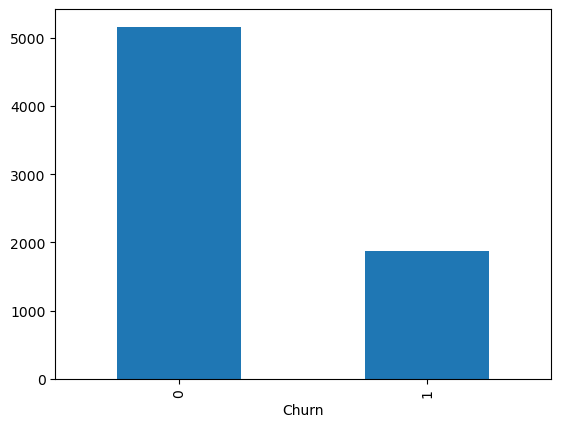

In [69]:
y.value_counts().plot(kind='bar')
plt.show()

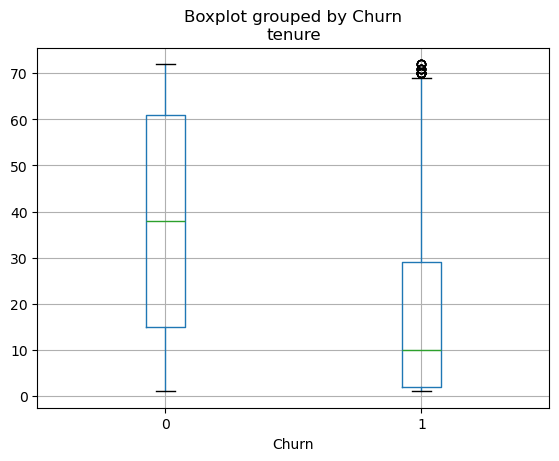

In [77]:
df.boxplot(column='tenure', by='Churn')
plt.show()

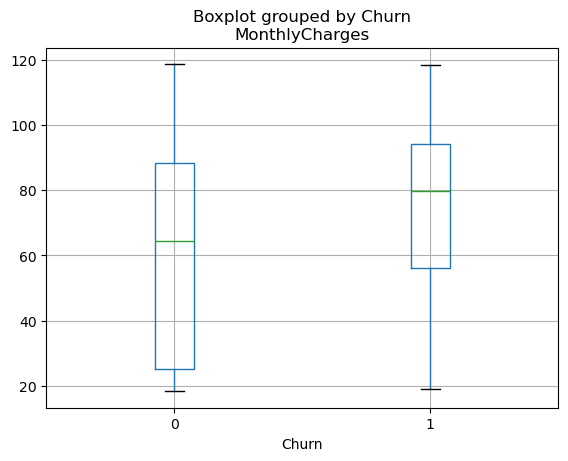

In [85]:
df.boxplot(column='MonthlyCharges', by='Churn')
plt.show()

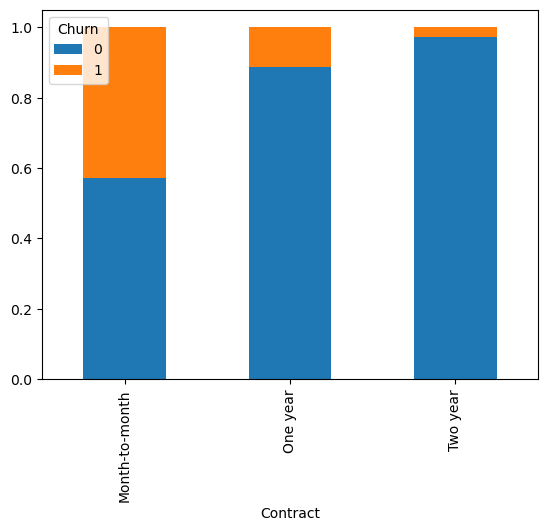

In [91]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(kind="bar", stacked=True)
plt.show()

In [93]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

In [95]:
baseline_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

In [97]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['customerID', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [99]:
y_base_pred = baseline_model.predict(X_test)

In [101]:
print(confusion_matrix(y_test, y_base_pred))

[[918 115]
 [181 193]]


In [103]:
print(classification_report(y_test, y_base_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [105]:
baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_base_pred),
    "f1": f1_score(y_test, y_base_pred),
    "recall": recall_score(y_test, y_base_pred),
    "precision": precision_score(y_test, y_base_pred)
}

In [107]:
baseline_metrics

{'accuracy': 0.7896233120113717,
 'f1': 0.5659824046920822,
 'recall': 0.516042780748663,
 'precision': 0.6266233766233766}

In [109]:
lgb_train = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=cat_cols,
    free_raw_data=False
)

In [113]:
lgb_valid = lgb.Dataset(
    X_test,
    label=y_test,
    categorical_feature=cat_cols,
    free_raw_data=False
)

In [173]:
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 6,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
    "seed": 42,
    "max_data_in_leaf":50,
    "min_gain_to_split":0.0,
    "lambda_l1":0.0,
    "lambda_l2":1.0,
    "is_unbalance":True
}

In [175]:
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=100)
]

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=callbacks
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[29]	train's binary_logloss: 0.431261	valid's binary_logloss: 0.473674


In [177]:
y_proba_lgb = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

In [179]:
y_pred_lgb = (y_proba_lgb >= 0.5).astype(int)

In [181]:
print(confusion_matrix(y_test, y_pred_lgb))

[[806 227]
 [108 266]]


In [183]:
print(classification_report(y_test, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



In [185]:
lgb_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_lgb),
    "precision": precision_score(y_test, y_pred_lgb),
    "recall": recall_score(y_test, y_pred_lgb),
    "f1": f1_score(y_test, y_pred_lgb),
}

In [187]:
lgb_metrics

{'accuracy': 0.7619047619047619,
 'precision': 0.539553752535497,
 'recall': 0.7112299465240641,
 'f1': 0.6136101499423299}